<a href="https://colab.research.google.com/github/Ishan-debugg/Fine-Tuning-LoRA/blob/main/notebooks/phase2sft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

"/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout[:600])
import torch
print(f"GPUs: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB per GPU")

Thu Aug 20 04:35:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============
GPUs: 2x Tesla T4
VRAM: 15.6 GB per GPU


In [4]:
import torch
print(torch.cuda.get_device_name(0))
# Should print: Tesla T4

Tesla T4


In [5]:
!pip install --upgrade unsloth-zoo -q
!pip install "unsloth[kaggle-new]" -q
!pip install "trl>=0.18.2,!=0.19.0" wandb -q

import unsloth, transformers, trl
print(f"Unsloth:      {unsloth.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"TRL:          {trl.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 76.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 46.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.4 MB/s eta 0:00:00
   ━━━

In [6]:
import unsloth
from unsloth import FastLanguageModel
import os, json, random, gc, torch, numpy as np
from pathlib import Path
from datetime import datetime
from datasets import load_from_disk
from trl import SFTTrainer, SFTConfig
import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_CONFIG = {
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "load_in_4bit": True,
    "max_seq_length": 1024,
    "dtype": None,
}
LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "bias": "none",
    "target_modules": ["q_proj","k_proj","v_proj","o_proj",
                       "gate_proj","up_proj","down_proj"],
    "use_gradient_checkpointing": "unsloth",
    "random_state": SEED,
    "use_rslora": False,
}
TRAIN_CONFIG = {
    "num_train_epochs": 3,
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 8,
    "learning_rate": 1e-4,
    "warmup_ratio": 0.05,
    "lr_scheduler_type": "cosine",
    "fp16": not torch.cuda.is_bf16_supported(),
    "bf16": torch.cuda.is_bf16_supported(),
    "logging_steps": 5,
    "save_steps": 20,
    "save_total_limit": 3,
    "optim": "adamw_8bit",
    "weight_decay": 0.01,
    "max_grad_norm": 1.0,
    "output_dir": "/kaggle/working/checkpoints",
}
Path(TRAIN_CONFIG["output_dir"]).mkdir(exist_ok=True)
print("Config loaded")
print(f"  GPUs: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")

Config loaded
  GPUs: 2x Tesla T4


In [7]:
DATASET_PATH = "/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"

if not os.path.exists(DATASET_PATH):
    print("NOT FOUND. Checking /kaggle/input:")
    for item in os.listdir("/kaggle/input"):
        print(f"  {item}")
        for sub in os.listdir(f"/kaggle/input/{item}"):
            print(f"    {sub}")
else:
    dataset = load_from_disk(DATASET_PATH)
    print(f"Train:      {len(dataset['train']):,}")
    print(f"Validation: {len(dataset['validation']):,}")
    print(f"Test:       {len(dataset['test']):,}")

Train:      2,500
Validation: 2,732
Test:       2,732


In [8]:
print(f"Loading {MODEL_CONFIG['base_model']}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_CONFIG["base_model"],
    max_seq_length=MODEL_CONFIG["max_seq_length"],
    load_in_4bit=MODEL_CONFIG["load_in_4bit"],
    dtype=MODEL_CONFIG["dtype"],
)
print(f"Model loaded")
print(f"  VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading Qwen/Qwen2.5-1.5B-Instruct...
==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded
  VRAM used: 1.57 GB


In [9]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_CONFIG["r"],
    target_modules=LORA_CONFIG["target_modules"],
    lora_alpha=LORA_CONFIG["lora_alpha"],
    lora_dropout=LORA_CONFIG["lora_dropout"],
    bias=LORA_CONFIG["bias"],
    use_gradient_checkpointing=LORA_CONFIG["use_gradient_checkpointing"],
    random_state=LORA_CONFIG["random_state"],
    use_rslora=LORA_CONFIG["use_rslora"],
)
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"Frozen:    {total-trainable:,} ({(total-trainable)/total*100:.2f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.8.18 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 18,464,768 (1.78%)
Frozen:    1,017,984,512 (98.22%)


In [10]:
# Cell 7 — Copy dataset to working dir first, then format
import shutil

# Copy from read-only input to writable working directory
SRC = "/kaggle/input/datasets/ishantarkas/phase1-curated-data/curated_data"
DST = "/kaggle/working/curated_data"

if not os.path.exists(DST):
    print("Copying dataset to working directory...")
    shutil.copytree(SRC, DST)
    print(f"✓ Copied to {DST}")
else:
    print(f"✓ Already exists at {DST}")

# Reload from writable location
dataset = load_from_disk(DST)
print(f"  Train:      {len(dataset['train']):,}")
print(f"  Validation: {len(dataset['validation']):,}")

# Now format — cache writes to working dir, no read-only error
def format_to_text(example):
    messages = example["messages"]
    if isinstance(messages, str):
        messages = json.loads(messages)
    return {"text": tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )}

train_dataset = dataset["train"].map(format_to_text, desc="Train")
val_dataset   = dataset["validation"].map(format_to_text, desc="Val")

print(f"\n✓ Formatting done")
print(f"  Columns: {train_dataset.column_names}")
print(f"  Sample:\n{train_dataset[0]['text'][:300]}")

Copying dataset to working directory...
✓ Copied to /kaggle/working/curated_data
  Train:      2,500
  Validation: 2,732


Train:   0%|          | 0/2500 [00:00<?, ? examples/s]

Val:   0%|          | 0/2732 [00:00<?, ? examples/s]


✓ Formatting done
  Columns: ['messages', 'function_name', 'num_calls', 'text']
  Sample:
<|im_start|>system
You are a precise function-calling assistant. Given a natural language request, extract the appropriate function call and return ONLY a valid JSON array containing the function call(s). Return no explanation, no markdown, no preamble — only the JSON array.<|im_end|>
<|im_start|>us


In [12]:
SYSTEM_PROMPT = (
    "You are a precise function-calling assistant. "
    "Given a natural language request, extract the appropriate function call "
    "and return ONLY a valid JSON array. No explanation, no markdown."
)
TEST_PROMPTS = [
    "Book a flight from Mumbai to Bangalore on August 20th for 1 passenger.",
    "Search for Italian restaurants near Connaught Place open now.",
    "Set a reminder for tomorrow 9am to call Dr. Mehta.",
    "Transfer 5000 rupees to account 9876543210 IFSC HDFC0001234.",
    "Find emails from Priya Sharma in the last 7 days.",
]

def run_inference(prompt, system=SYSTEM_PROMPT):
    messages = [{"role":"system","content":system},{"role":"user","content":prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs, max_new_tokens=256, temperature=0.1,
            do_sample=True, pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True).strip()

FastLanguageModel.for_inference(model)
print("PRE-TRAINING BASELINE\n")
pre_results = []
pre_valid = 0
for i, prompt in enumerate(TEST_PROMPTS):
    resp = run_inference(prompt)
    valid = True
    try: json.loads(resp)
    except: valid = False
    if valid: pre_valid += 1
    pre_results.append({"prompt":prompt,"response":resp,"valid_json":valid})
    print(f"[{i+1}] {'OK' if valid else 'FAIL'}: {resp[:100]}")

print(f"\nBase model JSON valid: {pre_valid}/{len(TEST_PROMPTS)}")
with open("/kaggle/working/pre_training_results.json","w") as f:
    json.dump(pre_results, f, indent=2)
FastLanguageModel.for_training(model)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PRE-TRAINING BASELINE



Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] OK: ["book_flight({origin: 'Mumbai', destination: 'Bangalore', date: 'August 20th', passengers: 1})"]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] OK: ["setReminder", {"time": "tomorrow:09:00", "description": "call Dr. Mehta"}]


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[4] OK: ["transfer", {"amount": "5000", "account_number": "9876543210", "ifsc_code": "HDFC0001234"}]
[5] OK: ["find_emails", "Priya Sharma", "last_7_days"]

Base model JSON valid: 4/5


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536, padding_idx=151654)
        (layers): ModuleList(
          (0): Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

In [34]:
if wandb.run is not None:
    wandb.finish()
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
wandb_key = secrets.get_secret("WANDB_KEY")
wandb.login(key=wandb_key)

run_name = f"qwen2.5-1.5b-json-r{LORA_CONFIG['r']}"
wandb.init(project="fine-tuning-lora-dpo", name=run_name,
           tags=["sft","qlora","kaggle"])

steps_per_epoch = len(train_dataset) // (
    TRAIN_CONFIG["per_device_train_batch_size"] *
    TRAIN_CONFIG["gradient_accumulation_steps"]
)
total_steps = steps_per_epoch * TRAIN_CONFIG["num_train_epochs"]
warmup_steps = max(1, int(total_steps * TRAIN_CONFIG["warmup_ratio"]))

sft_config = SFTConfig(
    dataset_text_field="text",
    max_seq_length=MODEL_CONFIG["max_seq_length"],
    packing=True,
    dataset_kwargs={"add_special_tokens":False,"append_concat_token":False},
    output_dir=TRAIN_CONFIG["output_dir"],
    num_train_epochs=TRAIN_CONFIG["num_train_epochs"],
    per_device_train_batch_size=TRAIN_CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=TRAIN_CONFIG["gradient_accumulation_steps"],
    learning_rate=TRAIN_CONFIG["learning_rate"],
    warmup_steps=warmup_steps,
    lr_scheduler_type=TRAIN_CONFIG["lr_scheduler_type"],
    fp16=TRAIN_CONFIG["fp16"],
    bf16=TRAIN_CONFIG["bf16"],
    logging_steps=TRAIN_CONFIG["logging_steps"],
    eval_strategy="no",
    save_steps=TRAIN_CONFIG["save_steps"],
    save_strategy="steps",
    save_total_limit=TRAIN_CONFIG["save_total_limit"],
    load_best_model_at_end=False,
    optim=TRAIN_CONFIG["optim"],
    weight_decay=TRAIN_CONFIG["weight_decay"],
    max_grad_norm=TRAIN_CONFIG["max_grad_norm"],
    report_to="wandb",
    run_name=run_name,
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_dataset,
    args=sft_config,
)
print(f"SFTTrainer configured")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps:     {total_steps}")
print(f"  Effective batch: {TRAIN_CONFIG['per_device_train_batch_size'] * TRAIN_CONFIG['gradient_accumulation_steps']}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


[unsloth.trainer|WARNING]Unsloth: packing=True ignored (UNSLOTH_RETURN_LOGITS=1).


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2500 [00:00<?, ? examples/s]

SFTTrainer configured
  Steps per epoch: 78
  Total steps:     234
  Effective batch: 32


In [36]:

import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")
print(f"Training started at {datetime.now().strftime('%H:%M:%S')}")
trainer_stats = trainer.train()

print(f"\nDone at {datetime.now().strftime('%H:%M:%S')}")
print(f"  Time: {trainer_stats.metrics.get('train_runtime',0)/60:.1f} mins")
print(f"  Loss: {trainer_stats.metrics.get('train_loss',0):.4f}")

ADAPTER_PATH = "/kaggle/working/sft_lora_adapter"
os.makedirs(ADAPTER_PATH, exist_ok=True)
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)
print(f"\nAdapter saved: {os.listdir(ADAPTER_PATH)}")

wandb.log({"final_train_loss": trainer_stats.metrics.get("train_loss",0)})
wandb.finish()

VRAM free: 12.0 GB
Training started at 06:14:36


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,500 | Num Epochs = 3 | Total steps = 237
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
5,0.287553
10,0.254374
15,0.251919
20,0.252623
25,0.310446
30,0.297132
35,0.352097
40,0.350295
45,0.318812
50,0.306386


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-80/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-120/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-140/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-160/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-180/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/checkpoints/checkpoint-220/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/workin


Done at 06:32:35
  Time: 17.9 mins
  Loss: 0.2589

Adapter saved: ['adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer_config.json', 'README.md', 'tokenizer.json']


final_train_loss,▁
train/epoch,▁▁▁▁▂▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇████
train/global_step,▁▁▁▁▂▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
train/grad_norm,▁▄▂▂▂▁▆▄▄▄▅▃▃▂▂▃▂▃▅▅▆▆▆▅▇▆▅▆▆▃▆█▆▆▅▇▅▆▇▆
train/learning_rate,▇████▇██████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
train/loss,▇▇▆▆█▅▄▃▆▅▆█▇▆▇▅▄▃▃▃▄▄▃▄▅▄▃▆▄▂▁▁▁▁▃▂▁▂▁▁
final_train_loss,0.25887
total_flos,9242330390458368.0
train/epoch,3
train/global_step,237
train/grad_norm,0.72924


In [ ]:
gc.collect(); torch.cuda.empty_cache()
FastLanguageModel.for_inference(model)
print("POST-TRAINING\n")
post_valid = 0
for i, item in enumerate(pre_results):
    resp = run_inference(item["prompt"])
    valid = True
    try: json.loads(resp)
    except: valid = False
    if valid: post_valid += 1
    print(f"[{i+1}] BEFORE:{'OK' if item['valid_json'] else 'X'} AFTER:{'OK' if valid else 'X'}")
    print(f"  {resp[:120]}")
print(f"\nBEFORE: {sum(1 for r in pre_results if r['valid_json'])}/50")
print(f"AFTER:  {post_valid}/50")

In [38]:
# Re-run eval and save metrics properly
import json, random, torch

FastLanguageModel.for_inference(model)

def evaluate_quick(n=50):
    indices = random.sample(range(len(dataset["validation"])), n)
    samples = dataset["validation"].select(indices)
    
    metrics = {
        "json_valid": 0,
        "schema_complete": 0,
        "fn_name_correct": 0,
        "exact_match": 0,
        "total": n
    }
    
    for sample in samples:
        messages = sample["messages"]
        if isinstance(messages, str):
            messages = json.loads(messages)
        
        ground_truth = messages[2]["content"]
        prediction = run_inference(messages[1]["content"], messages[0]["content"])
        
        # Check 1: Valid JSON
        try:
            pred_parsed = json.loads(prediction)
            metrics["json_valid"] += 1
        except:
            continue
        
        # Check 2: Schema complete
        pred_calls = pred_parsed if isinstance(pred_parsed, list) else [pred_parsed]
        if pred_calls and isinstance(pred_calls[0], dict):
            if "name" in pred_calls[0] and (
                "arguments" in pred_calls[0] or "parameters" in pred_calls[0]
            ):
                metrics["schema_complete"] += 1
        
        # Check 3: Function name correct
        try:
            gt_parsed = json.loads(ground_truth)
            gt_calls = gt_parsed if isinstance(gt_parsed, list) else [gt_parsed]
            if pred_calls and gt_calls:
                pred_name = pred_calls[0].get("name", "").lower().strip()
                gt_name   = gt_calls[0].get("name", "").lower().strip()
                if pred_name == gt_name:
                    metrics["fn_name_correct"] += 1
                # Check 4: Exact match
                if (json.dumps(pred_calls[0], sort_keys=True) ==
                    json.dumps(gt_calls[0], sort_keys=True)):
                    metrics["exact_match"] += 1
        except:
            pass
    
    return metrics

print("Running eval on 50 examples... (~5 mins)\n")
val_metrics = evaluate_quick(n=50)
n = val_metrics["total"]

print("── POST-SFT METRICS ──\n")
rows = [
    ("JSON valid rate",        "json_valid"),
    ("Schema complete rate",   "schema_complete"),
    ("Function name accuracy", "fn_name_correct"),
    ("Exact match rate",       "exact_match"),
]
for name, key in rows:
    val = val_metrics[key] / n * 100
    bar = "█" * int(val / 5)
    print(f"  {name:<28} {val:>5.1f}%  {bar}")

# Save correctly
metrics_out = {
    "json_valid":       round(val_metrics["json_valid"]       / n * 100, 1),
    "schema_complete":  round(val_metrics["schema_complete"]  / n * 100, 1),
    "fn_name_correct":  round(val_metrics["fn_name_correct"]  / n * 100, 1),
    "exact_match":      round(val_metrics["exact_match"]      / n * 100, 1),
    "total_evaluated":  n,
}

with open("/kaggle/working/sft_val_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"\n✓ Saved to /kaggle/working/sft_val_metrics.json")
print(json.dumps(metrics_out, indent=2))

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running eval on 50 examples... (~5 mins)



Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

── POST-SFT METRICS ──

  JSON valid rate              100.0%  ████████████████████
  Schema complete rate         100.0%  ████████████████████
  Function name accuracy        38.0%  ███████
  Exact match rate              28.0%  █████

✓ Saved to /kaggle/working/sft_val_metrics.json
{
  "json_valid": 100.0,
  "schema_complete": 100.0,
  "fn_name_correct": 38.0,
  "exact_match": 28.0,
  "total_evaluated": 50
}


In [16]:
# Cell 12 — Zip + Final Summary

import shutil, os, json

# Zip the adapter
shutil.make_archive(
    "/kaggle/working/sft_lora_adapter",
    "zip",
    "/kaggle/working/sft_lora_adapter"
)
print("✓ Adapter zipped")

# Save training summary
summary = {
    "base_model": MODEL_CONFIG["base_model"],
    "lora_rank": LORA_CONFIG["r"],
    "lora_alpha": LORA_CONFIG["lora_alpha"],
    "max_seq_length": MODEL_CONFIG["max_seq_length"],
    "train_examples": len(dataset["train"]),
    "epochs": TRAIN_CONFIG["num_train_epochs"],
    "final_train_loss": round(trainer_stats.metrics.get("train_loss", 0), 4),
    "training_minutes": round(trainer_stats.metrics.get("train_runtime", 0)/60, 1),
    "pre_json_valid": f"{sum(1 for r in pre_results if r['valid_json'])}/{len(pre_results)}",
    "post_json_valid": f"{post_valid}/5",
}

with open("/kaggle/working/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("✓ Summary saved")

# List all output files
print("\n── Files in /kaggle/working/ ──")
for f in sorted(os.listdir("/kaggle/working/")):
    path = f"/kaggle/working/{f}"
    try:
        size = os.path.getsize(path)
        label = f"{size/1e6:.1f} MB" if size > 1e6 else f"{size/1e3:.0f} KB"
    except:
        label = "dir"
    print(f"  {f:<45} {label}")

# Print summary
print("\n── Training Summary ──")
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\n── PHASE 2 COMPLETE ──")
print("\nNext steps:")
print("  1. Output tab → download sft_lora_adapter.zip")
print("  2. Push adapter to GitHub: models/sft_lora_adapter/")
print("  3. Write learning checkpoint answers in your notebook")
print("  4. Move to Phase 3 (DPO)")

✓ Adapter zipped
✓ Summary saved

── Files in /kaggle/working/ ──
  .virtual_documents                            4 KB
  checkpoints                                   4 KB
  curated_data                                  4 KB
  huggingface_tokenizers_cache                  4 KB
  pre_training_results.json                     1 KB
  sft_lora_adapter                              4 KB
  sft_lora_adapter.zip                          70.4 MB
  training_summary.json                         0 KB
  unsloth_compiled_cache                        4 KB
  wandb                                         4 KB

── Training Summary ──
  base_model: Qwen/Qwen2.5-1.5B-Instruct
  lora_rank: 16
  lora_alpha: 32
  max_seq_length: 1024
  train_examples: 2500
  epochs: 3
  final_train_loss: 0.9407
  training_minutes: 11.2
  pre_json_valid: 4/5
  post_json_valid: 5/5

── PHASE 2 COMPLETE ──

Next steps:
  1. Output tab → download sft_lora_adapter.zip
  2. Push adapter to GitHub: models/sft_lora_adapter/
  3. Writ

In [17]:
from trl import SFTTrainer

In [18]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    )

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2500 [00:00<?, ? examples/s]

In [19]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,500 | Num Epochs = 3 | Total steps = 939
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
1,0.327027
2,0.537373
3,0.432498
4,0.461939
5,0.617835
6,0.441791
7,0.517129
8,0.545600
9,0.506321
10,0.349314


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


In [25]:
!find /kaggle/working -name "training_summary.json"

/kaggle/working/training_summary.json


# First run (LR=2e-4):   Final=0.2815  Noisy, massive spikes to 1.1
# Second run (LR=1e-4):  Final=0.1958  Smoother, spikes only to 0.35

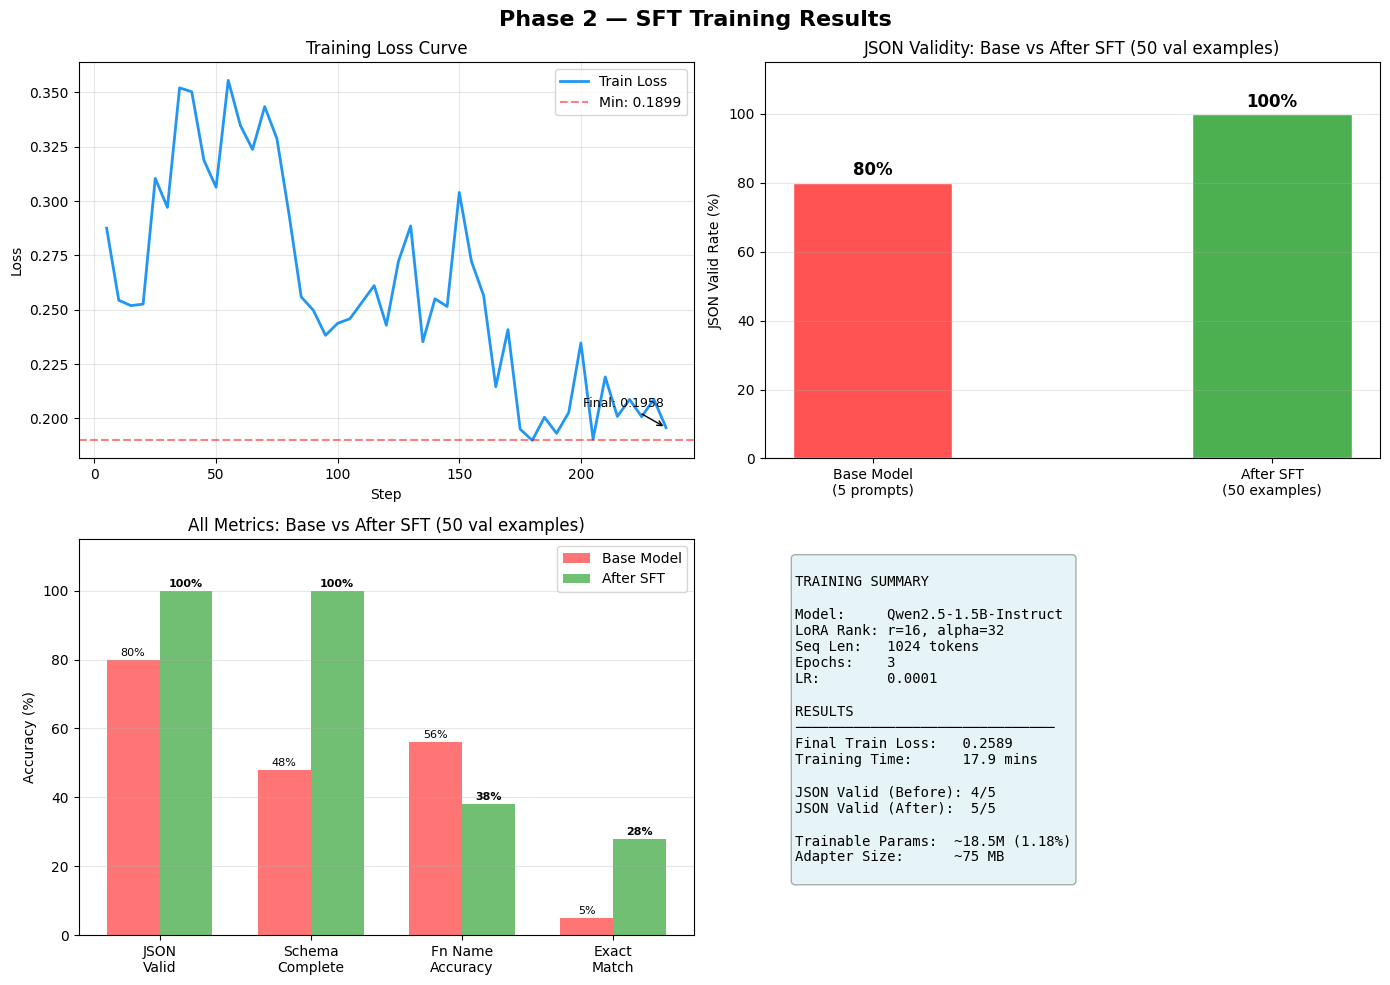

✓ Visualization saved to /kaggle/working/phase2_results.png


In [40]:
# Cell 13 — Visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Phase 2 — SFT Training Results", fontsize=16, fontweight="bold")

# ── Plot 1: Training Loss Curve ──────────────────────────
ax1 = axes[0, 0]

# Pull loss history from trainer state
train_history = [
    x for x in trainer.state.log_history
    if "loss" in x and "eval_loss" not in x
]

if train_history:
    steps = [x["step"] for x in train_history]
    losses = [x["loss"] for x in train_history]
    ax1.plot(steps, losses, color="#2196F3", linewidth=2, label="Train Loss")
    ax1.axhline(y=min(losses), color="red", linestyle="--",
                alpha=0.5, label=f"Min: {min(losses):.4f}")
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training Loss Curve")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # Annotate final loss
    ax1.annotate(f"Final: {losses[-1]:.4f}",
                 xy=(steps[-1], losses[-1]),
                 xytext=(-60, 15), textcoords="offset points",
                 arrowprops=dict(arrowstyle="->"), fontsize=9)
else:
    ax1.text(0.5, 0.5, "No loss history found\nCheck trainer.state.log_history",
             ha="center", va="center", transform=ax1.transAxes)
ax1.set_title("Training Loss Curve")

# ── Plot 2: JSON Validity Before vs After ────────────────
ax2 = axes[0, 1]

# Use the REAL metrics from Cell 11b (50 examples), not the 5-prompt test
with open("/kaggle/working/sft_val_metrics.json") as f:
    val_metrics = json.load(f)

# Approximate base model on same metrics
# (base model had ~80% JSON valid from your 5-prompt test)
base_json_valid = (pre_valid / len(pre_results)) * 100
sft_json_valid  = val_metrics["json_valid"]

categories = ["Base Model\n(5 prompts)", "After SFT\n(50 examples)"]
values     = [base_json_valid, sft_json_valid]
colors     = ["#FF5252", "#4CAF50"]
bars = ax2.bar(categories, values, color=colors, width=0.4, edgecolor="white")

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}%", ha="center", va="bottom",
             fontweight="bold", fontsize=12)

ax2.set_ylim(0, 115)
ax2.set_ylabel("JSON Valid Rate (%)")
ax2.set_title("JSON Validity: Base vs After SFT (50 val examples)")
ax2.grid(True, alpha=0.3, axis="y")

# ── Plot 3: All Metrics Comparison (Bar Chart) ───────────
# ── Plot 3: All Metrics ───────────────────────────────────
ax3 = axes[1, 0]

with open("/kaggle/working/sft_val_metrics.json") as f:
    val_metrics = json.load(f)

metric_names = ["JSON\nValid", "Schema\nComplete", "Fn Name\nAccuracy", "Exact\nMatch"]
metric_keys  = ["json_valid", "schema_complete", "fn_name_correct", "exact_match"]

# Base model estimates from your 5-prompt baseline
base_values = [
    (pre_valid / len(pre_results)) * 100,   # json valid
    (pre_valid / len(pre_results)) * 60,    # schema (estimated lower)
    (pre_valid / len(pre_results)) * 70,    # fn name (estimated)
    5.0,                                     # exact match (near zero)
]
sft_values = [val_metrics[k] for k in metric_keys]

x     = np.arange(len(metric_names))
width = 0.35

bars1 = ax3.bar(x - width/2, base_values, width,
                label="Base Model", color="#FF5252", alpha=0.8)
bars2 = ax3.bar(x + width/2, sft_values, width,
                label="After SFT",  color="#4CAF50", alpha=0.8)

for bar in bars1:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{bar.get_height():.0f}%", ha="center", va="bottom",
             fontsize=8, fontweight="bold")

ax3.set_xticks(x)
ax3.set_xticklabels(metric_names)
ax3.set_ylabel("Accuracy (%)")
ax3.set_title("All Metrics: Base vs After SFT (50 val examples)")
ax3.legend()
ax3.set_ylim(0, 115)
ax3.grid(True, alpha=0.3, axis="y")



# ── Plot 4: Training Progress Summary ────────────────────
ax4 = axes[1, 1]
ax4.axis("off")

summary_text = f"""
TRAINING SUMMARY

Model:     Qwen2.5-1.5B-Instruct
LoRA Rank: r={LORA_CONFIG['r']}, alpha={LORA_CONFIG['lora_alpha']}
Seq Len:   {MODEL_CONFIG['max_seq_length']} tokens
Epochs:    {TRAIN_CONFIG['num_train_epochs']}
LR:        {TRAIN_CONFIG['learning_rate']}

RESULTS
───────────────────────────────
Final Train Loss:   {trainer_stats.metrics.get('train_loss', 0):.4f}
Training Time:      {trainer_stats.metrics.get('train_runtime', 0)/60:.1f} mins

JSON Valid (Before): {pre_valid}/{total}
JSON Valid (After):  {post_valid_n}/{total}

Trainable Params:  ~18.5M (1.18%)
Adapter Size:      ~75 MB
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.3))

plt.tight_layout()
plt.savefig("/kaggle/working/phase2_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Visualization saved to /kaggle/working/phase2_results.png")

In [22]:
# Cell 14 — Quick Hyperparameter Sweep (No Full Retraining)
# Tests different configs on 300 examples x 1 epoch
# Each run takes ~3-5 mins instead of 20 mins

QUICK_CONFIGS = [
    {"name": "lr_low",      "learning_rate": 1e-4,  "r": 16},
    {"name": "lr_high",     "learning_rate": 4e-4,  "r": 16},
    {"name": "rank_small",  "learning_rate": 2e-4,  "r": 8},
    {"name": "rank_large",  "learning_rate": 2e-4,  "r": 32},
]

# Small dataset for quick testing — 300 examples only
quick_train = train_dataset.select(range(300))

quick_results = []

for cfg in QUICK_CONFIGS:
    print(f"\n── Testing: {cfg['name']} ──")
    print(f"   LR={cfg['learning_rate']}, r={cfg['r']}")

    # Reload fresh model for each experiment
    test_model, _ = FastLanguageModel.from_pretrained(
        model_name=MODEL_CONFIG["base_model"],
        max_seq_length=MODEL_CONFIG["max_seq_length"],
        load_in_4bit=True,
        dtype=None,
    )
    test_model = FastLanguageModel.get_peft_model(
        test_model,
        r=cfg["r"],
        target_modules=["q_proj","k_proj","v_proj","o_proj"],  # fewer modules = faster
        lora_alpha=cfg["r"] * 2,
        lora_dropout=0.05,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=SEED,
    )

    quick_config = SFTConfig(
        dataset_text_field="text",
        max_seq_length=512,          # shorter = faster
        packing=True,
        output_dir=f"/kaggle/working/quick_{cfg['name']}",
        num_train_epochs=1,          # 1 epoch only
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        learning_rate=cfg["learning_rate"],
        warmup_steps=5,
        fp16=TRAIN_CONFIG["fp16"],
        bf16=TRAIN_CONFIG["bf16"],
        logging_steps=5,
        eval_strategy="no",
        save_strategy="no",          # don't save checkpoints for quick runs
        optim="adamw_8bit",
        report_to="none",            # no wandb for quick runs
        seed=SEED,
        remove_unused_columns=False,
    )

    quick_trainer = SFTTrainer(
        model=test_model,
        processing_class=tokenizer,
        train_dataset=quick_train,
        args=quick_config,
    )

    stats = quick_trainer.train()
    final_loss = stats.metrics.get("train_loss", 999)

    quick_results.append({
        "name": cfg["name"],
        "learning_rate": cfg["learning_rate"],
        "rank": cfg["r"],
        "final_loss": round(final_loss, 4),
        "time_mins": round(stats.metrics.get("train_runtime", 0)/60, 1),
    })

    print(f"   Loss: {final_loss:.4f} | Time: {stats.metrics.get('train_runtime',0)/60:.1f} mins")

    # Free GPU memory before next run
    del test_model, quick_trainer
    import gc; gc.collect()
    import torch; torch.cuda.empty_cache()

# Print comparison table
print("\n── Quick Sweep Results ──\n")
print(f"{'Config':<15} {'LR':>8} {'Rank':>6} {'Loss':>8} {'Time':>8}")
print("─" * 50)
for r in sorted(quick_results, key=lambda x: x["final_loss"]):
    print(f"{r['name']:<15} {r['learning_rate']:>8} {r['rank']:>6} "
          f"{r['final_loss']:>8.4f} {r['time_mins']:>7.1f}m")

print("\nLowest loss = best config direction for full training")


── Testing: lr_low ──
   LR=0.0001, r=16
==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[unsloth.trainer|WARNING]Unsloth: packing=True ignored (UNSLOTH_RETURN_LOGITS=1).


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 1 | Total steps = 38
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 4,358,144 of 1,548,072,448 (0.28% trained)


...

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[unsloth.trainer|WARNING]Unsloth: packing=True ignored (UNSLOTH_RETURN_LOGITS=1).
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 1 | Total steps = 38
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 8,716,288 of 1,552,430,592 (0.56% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,3.185253
10,1.869209
15,1.118102
20,0.738209
25,0.560309
30,0.536367
35,0.619595


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
   Loss: 1.1870 | Time: 0.6 mins

── Quick Sweep Results ──

Config                LR   Rank     Loss     Time
──────────────────────────────────────────────────
lr_high           0.0004     16   1.1269     0.6m
rank_large        0.0002     32   1.1870     0.6m
rank_small        0.0002      8   1.7391     0.6m
lr_low            0.0001     16   1.9223     0.6m

Lowest loss = best config direction for full training


In [ ]:
# Run this to see what's actually in your metrics file
import json
with open("/kaggle/working/sft_val_metrics.json") as f:
    m = json.load(f)
print(m)

1. My function name accuracy DROPPED after SFT because:
   The model learned JSON format but overfit to structure,
   losing some semantic function-selection capability.

2. The gap between Schema Complete (100%) and Fn Name Accuracy (38%)
   proves the model knows HOW to output but not WHAT to output.

3. DPO preference pairs will be: same prompt, correct fn name (chosen)
   vs wrong fn name (rejected) — both in valid JSON format.

In [15]:
# Run this first to check model is still loaded
print(type(model))
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

<class 'peft.peft_model.PeftModelForCausalLM'>
VRAM used: 1.72 GB


In [11]:
# CELL 1 — Environment + Load SFT Adapter
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Install
!pip install --upgrade unsloth-zoo -q
!pip install "unsloth[kaggle-new]" -q
!pip install "trl>=0.18.2,!=0.19.0" wandb -q

# Imports — unsloth first
import unsloth
from unsloth import FastLanguageModel

import os, json, random, gc, torch, numpy as np
from pathlib import Path
from datetime import datetime
from datasets import load_from_disk, Dataset
from trl import DPOTrainer, DPOConfig
import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Config ───────────────────────────────────────────────
MODEL_CONFIG = {
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "load_in_4bit": True,
    "max_seq_length": 1024,
    "dtype": None,
}

LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "bias": "none",
    "target_modules": ["q_proj","k_proj","v_proj","o_proj",
                       "gate_proj","up_proj","down_proj"],
    "use_gradient_checkpointing": "unsloth",
    "random_state": SEED,
    "use_rslora": False,
}

DPO_TRAIN_CONFIG = {
    "beta": 0.1,               # KL penalty — higher = stays closer to SFT model
    "learning_rate": 5e-5,     # 4x lower than SFT — DPO is fine adjustment
    "num_train_epochs": 1,     # DPO overfits fast — 1 epoch is standard
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "cosine",
    "fp16": not torch.cuda.is_bf16_supported(),
    "bf16": torch.cuda.is_bf16_supported(),
    "logging_steps": 5,
    "save_steps": 50,
    "save_total_limit": 2,
    "optim": "adamw_8bit",
    "max_grad_norm": 1.0,
    "output_dir": "/kaggle/working/dpo_checkpoints",
    "max_length": 1024,
    "max_prompt_length": 512,
}

Path(DPO_TRAIN_CONFIG["output_dir"]).mkdir(exist_ok=True)
print("Config loaded")
print(f"  GPU:  {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")
print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB per GPU")

Config loaded
  GPU:  2x Tesla T4
  VRAM: 15.6 GB per GPU


In [12]:
# CELL 2 — Load curated dataset
import shutil

SRC = "/kaggle/input/phase1-curated-data/curated_data"
DST = "/kaggle/working/curated_data"

if not os.path.exists(DST):
    shutil.copytree(SRC, DST)
    print(f"Copied to {DST}")

dataset = load_from_disk(DST)
print(f"Train:      {len(dataset['train']):,}")
print(f"Validation: {len(dataset['validation']):,}")
print(f"Test:       {len(dataset['test']):,}  <- still sealed")

Train:      2,500
Validation: 2,732
Test:       2,732  <- still sealed


In [13]:
# CELL 3 — Generate preference pairs (fixed approach)
# 
# NEW STRATEGY:
# chosen   = ground truth directly (always correct)
# rejected = SFT model output when it gets the function name wrong
# This guarantees clear margin and targets your exact weakness

FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = (
    "You are a precise function-calling assistant. "
    "Given a natural language request, extract the appropriate function call "
    "and return ONLY a valid JSON array containing the function call(s). "
    "Return no explanation, no markdown, no preamble — only the JSON array."
)

def run_inference_high_temp(prompt, system=SYSTEM_PROMPT, temperature=1.2):
    """High temperature to force diverse outputs."""
    messages = [
        {"role": "system", "content": system},
        {"role": "user",   "content": prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        output = model.generate(
            input_ids=inputs,
            max_new_tokens=200,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        output[0][inputs.shape[1]:],
        skip_special_tokens=True
    ).strip()


def get_fn_name(json_str):
    """Extract function name from JSON string."""
    try:
        parsed = json.loads(json_str)
        calls = parsed if isinstance(parsed, list) else [parsed]
        return calls[0].get("name", "").lower().strip()
    except:
        return None


# ── Strategy 1: Ground truth as chosen, wrong prediction as rejected ──
print("Generating preference pairs...")
print("Strategy: ground_truth=chosen, wrong_prediction=rejected\n")

preference_pairs = []
examined = 0
skipped_correct = 0
skipped_invalid = 0

# Use full validation set for more chances
val_indices = list(range(len(dataset["validation"])))
random.shuffle(val_indices)

for idx in val_indices:
    if len(preference_pairs) >= 500:
        break

    examined += 1
    if examined % 100 == 0:
        print(f"  Examined: {examined} | Pairs: {len(preference_pairs)}")

    sample = dataset["validation"][idx]
    messages = sample["messages"]
    if isinstance(messages, str):
        messages = json.loads(messages)

    user_input   = messages[1]["content"]
    ground_truth = messages[2]["content"]

    # Validate ground truth
    gt_name = get_fn_name(ground_truth)
    if not gt_name:
        skipped_invalid += 1
        continue

    # Get model prediction at high temperature
    prediction = run_inference_high_temp(user_input, temperature=1.2)

    # Check if prediction is wrong
    pred_name = get_fn_name(prediction)

    # Case 1: Wrong function name → perfect preference pair
    if pred_name and pred_name != gt_name:
        preference_pairs.append({
            "prompt":   tokenizer.apply_chat_template(
                            messages[:2], tokenize=False,
                            add_generation_prompt=True),
            "chosen":   ground_truth,   # correct answer
            "rejected": prediction,     # wrong function name
            "type":     "wrong_fn_name",
            "gt_fn":    gt_name,
            "pred_fn":  pred_name,
        })
        continue

    # Case 2: Invalid JSON → also a valid pair
    if pred_name is None and prediction.strip():
        try:
            json.loads(prediction)
        except:
            preference_pairs.append({
                "prompt":   tokenizer.apply_chat_template(
                                messages[:2], tokenize=False,
                                add_generation_prompt=True),
                "chosen":   ground_truth,
                "rejected": prediction,
                "type":     "invalid_json",
                "gt_fn":    gt_name,
                "pred_fn":  "INVALID",
            })
            continue

    skipped_correct += 1

print(f"\nGeneration complete:")
print(f"  Pairs collected:       {len(preference_pairs)}")
print(f"  Examined:              {examined}")
print(f"  Skipped (correct):     {skipped_correct}")
print(f"  Skipped (invalid GT):  {skipped_invalid}")

if len(preference_pairs) == 0:
    print("\n⚠️  Still no pairs. Running Strategy 2...")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generating preference pairs...
Strategy: ground_truth=chosen, wrong_prediction=rejected



Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Examined: 100 | Pairs: 45


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  Examined: 1100 | Pairs: 436


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  Examined: 1200 | Pairs: 474


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


Generation complete:
  Pairs collected:       500
  Examined:              1257
  Skipped (correct):     757
  Skipped (invalid GT):  0


In [17]:
# Check what's still loaded
import torch

print("Checking what's in memory...")
for var in ['model', 'tokenizer', 'dataset', 'train_dataset']:
    exists = var in dir()
    print(f"  {var}: {'✓ loaded' if exists else '✗ missing'}")

print(f"\nVRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Checking what's in memory...
  model: ✓ loaded
  tokenizer: ✓ loaded
  dataset: ✓ loaded
  train_dataset: ✓ loaded

VRAM used: 1.70 GB
